In [10]:
import torch
print(torch.backends.cudnn.enabled)  # Should print True
print(torch.version.cuda)  # Should print '12.8' if correctly installed


True
11.8


In [11]:
import torch
print("CUDA Available:", torch.cuda.is_available())  # Should be True
print("CUDA Version:", torch.version.cuda)  # Should match your installed CUDA
print("cuDNN Enabled:", torch.backends.cudnn.enabled)  # Should be True
print("cuDNN Version:", torch.backends.cudnn.version())  # Should print a version number


CUDA Available: True
CUDA Version: 11.8
cuDNN Enabled: True
cuDNN Version: 90100


In [ ]:
# Install other dependencies
%pip install opencv-python pandas matplotlib tqdm seaborn

# Install YOLO requirements
%pip install ultralytics

In [13]:
!git clone https://github.com/ultralytics/yolov5.git
!git clone https://github.com/WongKinYiu/yolov7.git
!git clone https://github.com/ultralytics/ultralytics.git


fatal: destination path 'yolov5' already exists and is not an empty directory.
fatal: destination path 'yolov7' already exists and is not an empty directory.
fatal: destination path 'ultralytics' already exists and is not an empty directory.


In [14]:
import os
import shutil
import random
import glob

In [15]:
# Step 2: Install Dependencies
os.system("pip install -r yolov5/requirements.txt")
os.system("pip install -r yolov7/requirements.txt")
os.system("pip install ultralytics")


0

In [16]:
import os

def create_dirs():
    dirs = [
        "train/images", "train/labels",
        "valid/images", "valid/labels",
        "test/images", "test/labels"
    ]
    
    for dir in dirs:
        os.makedirs(dir, exist_ok=True)
    
    print("Directories created successfully!")

create_dirs()



Directories created successfully!


In [17]:
import os
import shutil

def split_dataset():
    allImages = [f for f in os.listdir("export/images/") if f.endswith(".jpg")]
    
    testCount = int(0.2 * len(allImages) / 10)
    trainCount = len(allImages) / 10 - testCount - 1
    valCount = int(0.2 * trainCount)
    trainCount = trainCount - valCount - 1
    
    print(trainCount, valCount, testCount)
    
    trainImages, valImages, testImages = [], [], []
    
    for i in range(int(len(allImages) / 10)):
        if i < trainCount:
            trainImages.append(allImages[i])
        elif i < (valCount + trainCount):
            valImages.append(allImages[i])
        else:
            testImages.append(allImages[i])
    
    print(len(trainImages), len(valImages), len(testImages))
    
    # Moving images
    for fileT in trainImages:
        shutil.move(f"export/images/{fileT}", f"train/images/{fileT}")
    for fileT in valImages:
        shutil.move(f"export/images/{fileT}", f"valid/images/{fileT}")
    for fileT in testImages:
        shutil.move(f"export/images/{fileT}", f"test/images/{fileT}")
    
    # Moving labels
    for fileT in trainImages:
        shutil.move(f"export/labels/{fileT.replace('.jpg', '.txt')}", f"train/labels/{fileT.replace('.jpg', '.txt')}")
    for fileT in valImages:
        shutil.move(f"export/labels/{fileT.replace('.jpg', '.txt')}", f"valid/labels/{fileT.replace('.jpg', '.txt')}")
    for fileT in testImages:
        shutil.move(f"export/labels/{fileT.replace('.jpg', '.txt')}", f"test/labels/{fileT.replace('.jpg', '.txt')}")

    print("Dataset successfully split and moved!")

split_dataset()


1715.0 429 536
1715 429 538
Dataset successfully split and moved!


In [18]:
import yaml

# Load YAML file
with open("data.yaml", "r") as file:
    data = yaml.safe_load(file)

# Print the extracted data
print(data)

# Access specific values (example)
print("Train path:", data.get("train"))
print("Validation path:", data.get("val"))
print("Number of classes:", data.get("nc"))
print("Class names:", data.get("names"))


{'train': '../train/images', 'val': '../valid/images', 'test': '../test/images', 'nc': 11, 'names': ['biker', 'car', 'pedestrian', 'trafficLight', 'trafficLight-Green', 'trafficLight-GreenLeft', 'trafficLight-Red', 'trafficLight-RedLeft', 'trafficLight-Yellow', 'trafficLight-YellowLeft', 'truck'], 'roboflow': {'workspace': 'roboflow-gw7yv', 'project': 'self-driving-car', 'version': 3, 'license': 'MIT', 'url': 'https://universe.roboflow.com/roboflow-gw7yv/self-driving-car/dataset/3'}}
Train path: ../train/images
Validation path: ../valid/images
Number of classes: 11
Class names: ['biker', 'car', 'pedestrian', 'trafficLight', 'trafficLight-Green', 'trafficLight-GreenLeft', 'trafficLight-Red', 'trafficLight-RedLeft', 'trafficLight-Yellow', 'trafficLight-YellowLeft', 'truck']


In [19]:
import yaml

with open("data.yaml", 'r') as stream:
    num_classes = str(yaml.safe_load(stream)['nc'])

print(f"Number of classes: {num_classes}")


Number of classes: 11


In [20]:
import yaml

file_path = "yolov5/models/yolov5s.yaml"

with open(file_path, "r") as file:
    yolov5_config = yaml.safe_load(file)

# Print the extracted data
print(yolov5_config)

# Access specific values (example)
print("Backbone:", yolov5_config.get("backbone"))
print("Number of classes:", yolov5_config.get("nc"))


{'anchors': [[10, 13, 16, 30, 33, 23], [30, 61, 62, 45, 59, 119], [116, 90, 156, 198, 373, 326]], 'backbone': [[-1, 1, 'Conv', [64, 6, 2, 2]], [-1, 1, 'Conv', [128, 3, 2]], [-1, 3, 'C3', [128]], [-1, 1, 'Conv', [256, 3, 2]], [-1, 6, 'C3', [256]], [-1, 1, 'Conv', [512, 3, 2]], [-1, 9, 'C3', [512]], [-1, 1, 'Conv', [1024, 3, 2]], [-1, 3, 'C3', [1024]], [-1, 1, 'SPPF', [1024, 5]]], 'depth_multiple': 0.33, 'head': [[-1, 1, 'Conv', [512, 1, 1]], [-1, 1, 'nn.Upsample', ['None', 2, 'nearest']], [[-1, 6], 1, 'Concat', [1]], [-1, 3, 'C3', [512, False]], [-1, 1, 'Conv', [256, 1, 1]], [-1, 1, 'nn.Upsample', ['None', 2, 'nearest']], [[-1, 4], 1, 'Concat', [1]], [-1, 3, 'C3', [256, False]], [-1, 1, 'Conv', [256, 3, 2]], [[-1, 14], 1, 'Concat', [1]], [-1, 3, 'C3', [512, False]], [-1, 1, 'Conv', [512, 3, 2]], [[-1, 10], 1, 'Concat', [1]], [-1, 3, 'C3', [1024, False]], [[17, 20, 23], 1, 'Detect', ['nc', 'anchors']]], 'nc': 11, 'width_multiple': 0.5}
Backbone: [[-1, 1, 'Conv', [64, 6, 2, 2]], [-1, 1, '

In [7]:
#customize iPython writefile so we can write variables
from IPython.core.magic import register_line_cell_magic

@register_line_cell_magic
def writetemplate(line, cell):
    with open(line, 'w') as f:
        f.write(cell.format(**globals()))

In [22]:
import yaml

# Load dataset config
with open("data.yaml", "r") as file:
    dataset_config = yaml.safe_load(file)
num_classes = dataset_config["nc"]

# Load YOLO model config
model_path = "yolov5/models/yolov5s.yaml"
with open(model_path, "r") as file:
    model_config = yaml.safe_load(file)

# Update the number of classes
model_config["nc"] = num_classes

# Save the updated model config
with open(model_path, "w") as file:
    yaml.safe_dump(model_config, file, default_flow_style=False)

print(f"Updated YOLOv5 model to {num_classes} classes.")


Updated YOLOv5 model to 11 classes.


In [23]:
import os
print(os.getcwd())  # Should print the yolov5 directory


e:\rspuram


In [ ]:
import os
os.remove("C:/Users/Hepzi/AppData/Roaming/Ultralytics/settings.json")



In [ ]:
%cd E:/rspuram/yolov5
!python train.py --img 416 --batch 16 --epochs 10 --data "E:/rspuram/data.yaml" --cfg "E:/rspuram/yolov5/models/yolov5s.yaml" --weights yolov5s.pt --name yolov5s_results --cache --workers 0


E:\rspuram\yolov5
^C


train: weights=yolov5s.pt, cfg=E:/rspuram/yolov5/models/yolov5s.yaml, data=E:/rspuram/data.yaml, hyp=data\hyps\hyp.scratch-low.yaml, epochs=10, batch_size=16, imgsz=416, rect=False, resume=False, nosave=False, noval=False, noautoanchor=False, noplots=False, evolve=None, evolve_population=data\hyps, resume_evolve=None, bucket=, cache=ram, image_weights=False, device=, multi_scale=False, single_cls=False, optimizer=SGD, sync_bn=False, workers=0, project=runs\train, name=yolov5s_results, exist_ok=False, quad=False, cos_lr=False, label_smoothing=0.0, patience=100, freeze=[0], save_period=-1, seed=0, local_rank=-1, entity=None, upload_dataset=False, bbox_interval=-1, artifact_alias=latest, ndjson_console=False, ndjson_file=False
github:  YOLOv5 is out of date by 4 commits. Use 'git pull' or 'git clone https://github.com/ultralytics/yolov5' to update.
YOLOv5  v7.0-405-g61c22e2d Python-3.9.21 torch-2.6.0+cu118 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)

hyperparameters: lr0=0.01, lr

In [4]:
import os
os.chdir("E:/rspuram/yolov5")

!python val.py --weights E:/rspuram/yolov5/runs/train/yolov5s_results5/weights/best.pt --data E:/rspuram/data.yaml --img 416


val: data=E:/rspuram/data.yaml, weights=['E:/rspuram/yolov5/runs/train/yolov5s_results5/weights/best.pt'], batch_size=32, imgsz=416, conf_thres=0.001, iou_thres=0.6, max_det=300, task=val, device=, workers=8, single_cls=False, augment=False, verbose=False, save_txt=False, save_hybrid=False, save_conf=False, save_json=False, project=runs\val, name=exp, exist_ok=False, half=False, dnn=False
YOLOv5  v7.0-405-g61c22e2d Python-3.9.21 torch-2.6.0+cu118 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)

Fusing layers... 
YOLOv5s summary: 157 layers, 7039792 parameters, 0 gradients, 15.8 GFLOPs

val: Scanning E:\rspuram\valid\labels...:   0%|          | 0/905 [00:00<?, ?it/s]
val: Scanning E:\rspuram\valid\labels... 1 images, 0 backgrounds, 0 corrupt:   0%|          | 1/905 [00:06<1:45:16,  6.99s/it]
val: Scanning E:\rspuram\valid\labels... 208 images, 0 backgrounds, 0 corrupt:  23%|██▎       | 208/905 [00:07<00:16, 41.60it/s]
val: Scanning E:\rspuram\valid\labels... 683 images, 0 backgroun

In [1]:
import os
os.chdir("E:/rspuram/yolov5")
!python val.py --weights E:/rspuram/yolov5/runs/train/yolov5s_results5/weights/best.pt --data E:/rspuram/data.yaml --img 416 --verbose


val: data=E:/rspuram/data.yaml, weights=['E:/rspuram/yolov5/runs/train/yolov5s_results5/weights/best.pt'], batch_size=32, imgsz=416, conf_thres=0.001, iou_thres=0.6, max_det=300, task=val, device=, workers=8, single_cls=False, augment=False, verbose=True, save_txt=False, save_hybrid=False, save_conf=False, save_json=False, project=runs\val, name=exp, exist_ok=False, half=False, dnn=False
YOLOv5  v7.0-405-g61c22e2d Python-3.9.21 torch-1.10.0+cpu CPU

Fusing layers... 
YOLOv5s summary: 157 layers, 7039792 parameters, 0 gradients, 15.8 GFLOPs

val: Scanning E:\rspuram\valid\labels...:   0%|          | 0/905 [00:00<?, ?it/s]
val: Scanning E:\rspuram\valid\labels... 1 images, 0 backgrounds, 0 corrupt:   0%|          | 1/905 [00:05<1:27:32,  5.81s/it]
val: Scanning E:\rspuram\valid\labels... 43 images, 0 backgrounds, 0 corrupt:   5%|▍         | 43/905 [00:05<01:24, 10.25it/s]
val: Scanning E:\rspuram\valid\labels... 78 images, 0 backgrounds, 0 corrupt:   9%|▊         | 78/905 [00:06<00:38, 2

In [5]:
import os
os.chdir("E:/rspuram/yolov5")

!python val.py --weights E:/rspuram/yolov5/runs/train/yolov5s_results5/weights/best.pt --data E:/rspuram/data.yaml --img 416


Error decoding JSON from C:\Users\Hepzi\AppData\Roaming\Ultralytics\settings.json. Starting with an empty dictionary.
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at 'C:\Users\Hepzi\AppData\Roaming\Ultralytics\settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Error decoding JSON from C:\Users\Hepzi\AppData\Roaming\Ultralytics\settings.json. Starting with an empty dictionary.
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at 'C:\Users\Hepzi\AppData\Roaming\Ultralytics\settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


val: data=E:/rspuram/data.yaml, weights=['E:/rspuram/yolov5/runs/train/yolov5s_results5/weights/best.pt'], batch_size=32, imgsz=416, conf_thres=0.001, iou_thres=0.6, max_det=300, task=val, device=, workers=8, single_cls=False, augment=False, verbose=False, save_txt=False, save_hybrid=False, save_conf=False, save_json=False, project=runs\val, name=exp, exist_ok=False, half=False, dnn=False
YOLOv5  v7.0-405-g61c22e2d Python-3.9.21 torch-1.10.0+cpu CPU

Fusing layers... 
YOLOv5s summary: 157 layers, 7039792 parameters, 0 gradients, 15.8 GFLOPs

val: Scanning E:\rspuram\valid\labels...:   0%|          | 0/905 [00:00<?, ?it/s]
val: Scanning E:\rspuram\valid\labels... 1 images, 0 backgrounds, 0 corrupt:   0%|          | 1/905 [00:05<1:19:38,  5.29s/it]
val: Scanning E:\rspuram\valid\labels... 370 images, 0 backgrounds, 0 corrupt:  41%|████      | 370/905 [00:05<00:05, 97.21it/s]
val: Scanning E:\rspuram\valid\labels... 822 images, 0 backgrounds, 0 corrupt:  91%|█████████ | 822/905 [00:05<00:

In [2]:
!python detect.py --weights E:/rspuram/yolov5/runs/train/yolov5s_results5/weights/best.pt --source E:/rspuram/test.jpg --img 416 --conf 0.4


detect: weights=['E:/rspuram/yolov5/runs/train/yolov5s_results5/weights/best.pt'], source=E:/rspuram/test.jpg, data=data\coco128.yaml, imgsz=[416, 416], conf_thres=0.4, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=False, save_format=0, save_csv=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs\detect, name=exp, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLOv5  v7.0-405-g61c22e2d Python-3.9.21 torch-1.10.0+cpu CPU

Fusing layers... 
YOLOv5s summary: 157 layers, 7039792 parameters, 0 gradients, 15.8 GFLOPs
image 1/1 E:\rspuram\test.jpg: 288x416 7 cars, 138.4ms
Speed: 0.0ms pre-process, 138.4ms inference, 1.0ms NMS per image at shape (1, 3, 416, 416)
Results saved to runs\detect\exp6


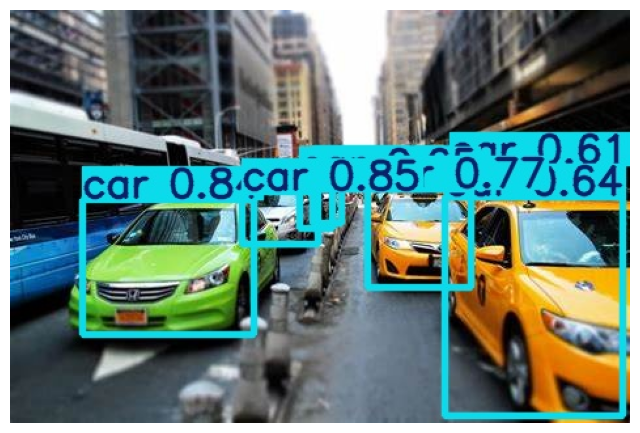

In [3]:
import matplotlib.pyplot as plt
import cv2
from IPython.display import display
from PIL import Image

# Load the latest detection result
output_image_path = "runs/detect/exp6/test.jpg"  # Change exp to expX if needed

# Load image with OpenCV (optional: convert BGR to RGB for correct colors)
image = cv2.imread(output_image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Display image using Matplotlib
plt.figure(figsize=(8, 6))
plt.imshow(image)
plt.axis("off")  # Hide axes
plt.show()


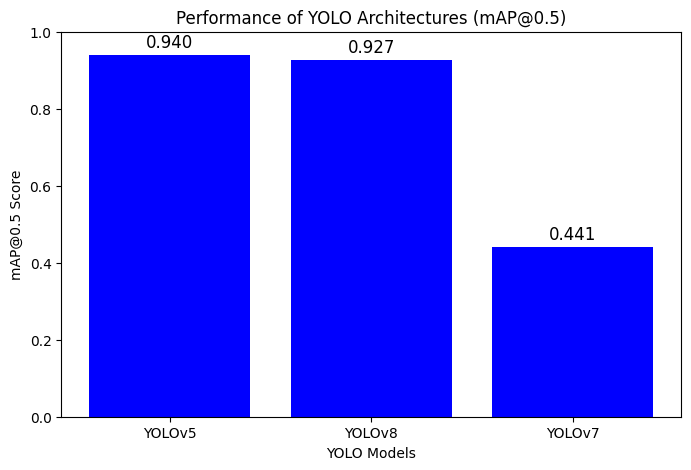

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# Data
models = ["YOLOv5", "YOLOv8", "YOLOv7"]
map_scores = [0.94, 0.927, 0.441]

# Bar chart
plt.figure(figsize=(8, 5))
plt.bar(models, map_scores, color=["blue", "blue", "blue"])

# Labels and title
plt.xlabel("YOLO Models")
plt.ylabel("mAP@0.5 Score")
plt.title("Performance of YOLO Architectures (mAP@0.5)")
plt.ylim(0, 1)  # Ensuring the scale is from 0 to 1 for better comparison

# Show values on bars
for i, v in enumerate(map_scores):
    plt.text(i, v + 0.02, f"{v:.3f}", ha='center', fontsize=12)

plt.show()


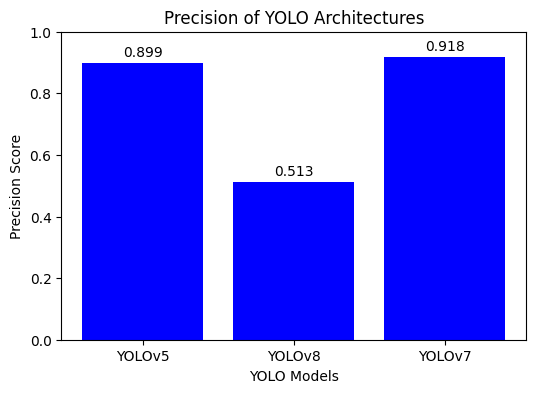

In [9]:
import matplotlib.pyplot as plt

# Data for precision
models = ["YOLOv5", "YOLOv8", "YOLOv7"]
precision = [0.899, 0.513, 0.918]

# Precision Bar Chart
plt.figure(figsize=(6, 4))
plt.bar(models, precision, color="blue")
plt.xlabel("YOLO Models")
plt.ylabel("Precision Score")
plt.title("Precision of YOLO Architectures")
plt.ylim(0, 1)

# Show values on bars
for i, v in enumerate(precision):
    plt.text(i, v + 0.02, f"{v:.3f}", ha='center', fontsize=10)

plt.show()


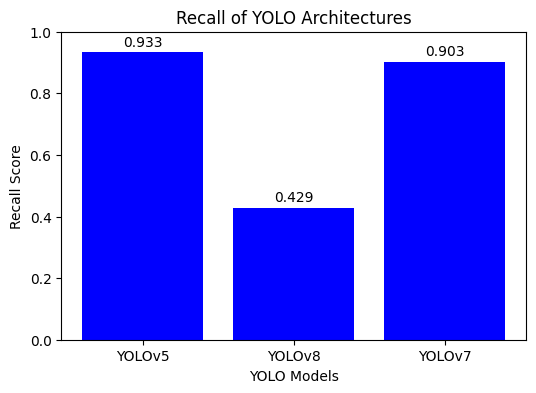

In [12]:
import matplotlib.pyplot as plt

# Data for recall
recall = [0.933, 0.429, 0.903]

# Recall Bar Chart
plt.figure(figsize=(6, 4))
plt.bar(models, recall, color="blue")
plt.xlabel("YOLO Models")
plt.ylabel("Recall Score")
plt.title("Recall of YOLO Architectures")
plt.ylim(0, 1)

# Show values on bars
for i, v in enumerate(recall):
    plt.text(i, v + 0.02, f"{v:.3f}", ha='center', fontsize=10)

plt.show()


In [2]:
import os
os.chdir("E:/rspuram/yolov5")
!python detect.py --weights E:/rspuram/yolov5/runs/train/yolov5s_results5/weights/best.pt --source E:/rspuram/tests --img 416 --conf 0.4


detect: weights=['E:/rspuram/yolov5/runs/train/yolov5s_results5/weights/best.pt'], source=E:/rspuram/tests, data=data\coco128.yaml, imgsz=[416, 416], conf_thres=0.4, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=False, save_format=0, save_csv=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs\detect, name=exp, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLOv5  v7.0-405-g61c22e2d Python-3.9.21 torch-1.10.0+cpu CPU

Fusing layers... 
YOLOv5s summary: 157 layers, 7039792 parameters, 0 gradients, 15.8 GFLOPs
image 1/20 E:\rspuram\tests\img (1).jpeg: 416x320 12 cars, 187.0ms
image 2/20 E:\rspuram\tests\img (10).jpeg: 416x320 1 car, 137.1ms
image 3/20 E:\rspuram\tests\img (11).jpeg: 416x320 4 cars, 109.3ms
image 4/20 E:\rspuram\tests\img (12).jpeg: 416x320 3 cars, 96.3ms
image 5/20 E:\rspuram\tests\img (13).jpeg: 416

In [ ]:
%matplotlib inline

import matplotlib.pyplot as plt
import cv2
import os
output_folder = "E:/rspuram/yolov5/runs/detect/exp9"

# List image files
image_files = [f for f in os.listdir(output_folder) if f.lower().endswith(('.jpg', '.png'))]

# Display one by one
for img_name in image_files:
    img_path = os.path.join(output_folder, img_name)

    image = cv2.imread(img_path)
    if image is None:
        print(f"Could not load image: {img_path}")
        continue

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(8, 6))
    plt.imshow(image)
    plt.title(f"Detection: {img_name}")
    plt.axis("off")
    plt.show()

    input("Press Enter to continue...")
